### Exercise 7
#### Exercise 07.2 
A partire da una configurazione cristallina perfetta, in fase liquida con $\rho^\star = 0.8$, $T^\star = 1.1$ e raggio di cut-off $r_c = 2.5$, si calcola la media progressiva dell’energia potenziale $U/N$ mediante il metodo Monte Carlo e la Dinamica Molecolare (*Molecular Dynamics*).

Prima di procedere, entrambe le simulazioni vengono equilibrate: per il metodo di Metropolis (Monte Carlo) si ottiene un tasso di accettazione di circa il $49$% con $\beta = 0.104$, mentre per la Molecular Dynamics si raggiunge una temperatura $T^\star = 1.1$, partendo da una temperatura iniziale $T = 1.43$.

A partire da questi dati si ottengono le seguenti grafiche:

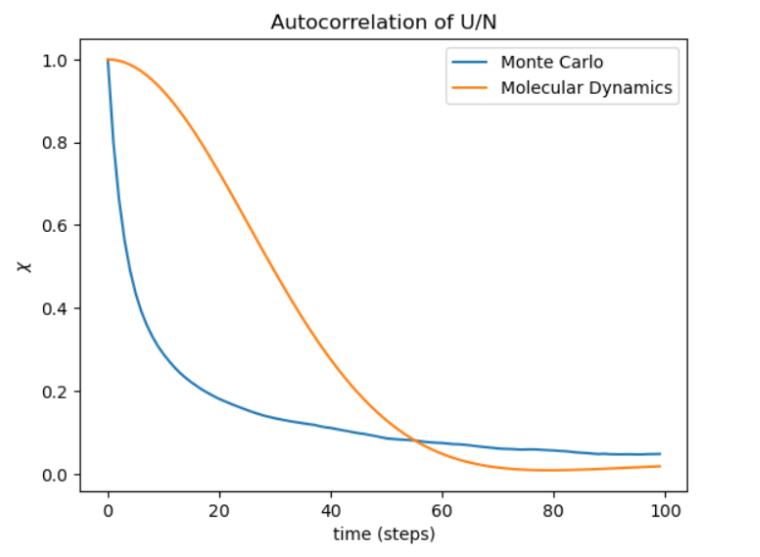

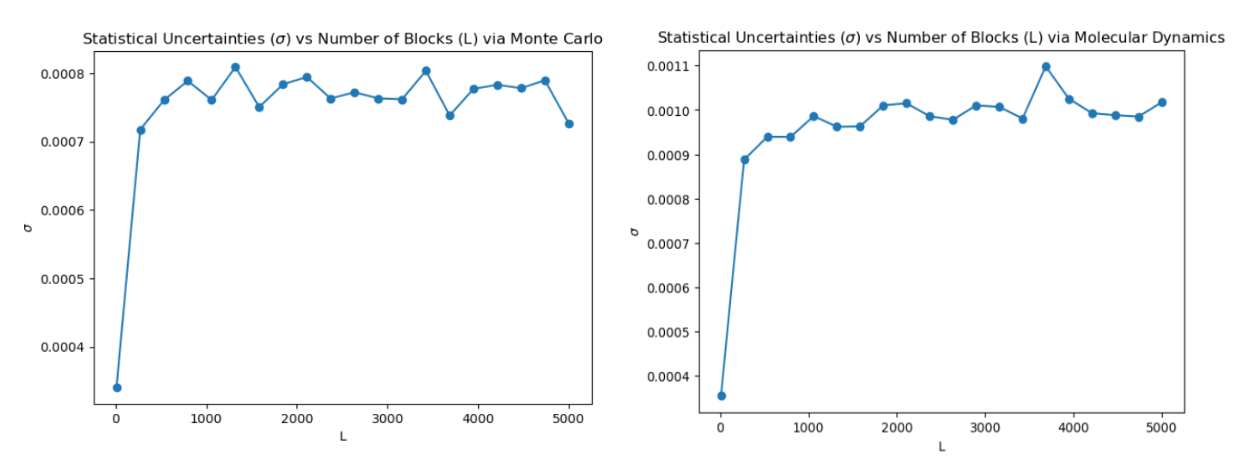

La prima figura mostra un confronto delle autocorrelazioni (analizzate sui primi $100$ passi, anche se l’intervallo potrebbe essere esteso), associate ai dati ottenuti. Si osserva che la curva corrispondente al metodo Monte Carlo decresce più rapidamente rispetto a quella della *Molecular Dynamics*, indicando che l’algoritmo di Monte Carlo possiede un tempo di correlazione minore e raggiunge più velocemente l’indipendenza statistica.

La seconda figura confronta le incertezze statistiche, evidenziando che queste raggiungono un valore costante a partire da $L \approx 1000$, indipendentemente dall’aumento ulteriore della dimensione dei blocchi. Ciò implica l’assenza di correlazione temporale significativa tra i blocchi.


In [ ]:
# Autocorrelation functions of U/N
import numpy as np
import math
import matplotlib.pyplot as plt

U_MC = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\U_inst_MC.dat")
U_MD = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\U_inst_MD.dat")

# Correlation function for MC
c_MC = np.correlate(U_MC - np.mean(U_MC), U_MC - np.mean(U_MC), mode= 'full')
c_MC = c_MC[c_MC.size//2:]
c_norm_MC = c_MC / c_MC[0]    # to normalice
    
# Correlation function for MD
c_MD = np.correlate(U_MD - np.mean(U_MD), U_MD - np.mean(U_MD), mode= 'full')
c_MD = c_MD[c_MD.size//2:]
c_norm_MD = c_MD / c_MD[0]    # to normalice

t_max = 100  # only the firts 100 steps
plt.plot(range(t_max), c_norm_MC[:t_max], label ='Monte Carlo')
plt.plot(range(t_max), c_norm_MD[:t_max], label = 'Molecular Dynamics')
plt.legend()
plt.title("Autocorrelation of U/N")
plt.xlabel("time (steps)")
plt.ylabel(r"$\chi$")
plt.show()

In [ ]:
# Statistical uncertainties as a function of L
import numpy as np
import math
import matplotlib.pyplot as plt
        
U = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\U_inst_MC.dat")
M = len(U)
print(f"Total de datos cargados: {M}")

L = np.linspace(10, 5000, 20).astype(int)        # L = M/N
error = []

for l in L:
    N = M // l   # Number of blocks

    U_blocks = U[:N*l].reshape(N, l)     # N blocks of size L
    L_ave = np.mean(U_blocks, axis=1)            # Media of each block

    # Errors
    ave = np.mean(L_ave)
    ave2 = np.mean(L_ave**2)
    err = math.sqrt((ave2-ave**2)/(N - 1))      # sigma / sqrt(N-1)
    error.append(err)

# plot
plt.figure(figsize=(7, 5))
plt.plot(L, error, 'o-')
plt.title("Statistical Uncertainties ($\sigma$) vs Number of Blocks (L) via Monte Carlo")
plt.xlabel("L")
plt.ylabel("$\sigma$")
plt.show()  

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
        
U = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\U_inst_MD.dat")
M = len(U)
print(f"Total de datos cargados: {M}")

L = np.linspace(10, 5000, 20).astype(int)        # L = M/N
error = []

for l in L:
    N = M // l   # Number of blocks

    U_blocks = U[:N*l].reshape(N, l)     # N blocks of size L
    L_ave = np.mean(U_blocks, axis=1)            # Media of each block

    # Errors
    ave = np.mean(L_ave)
    ave2 = np.mean(L_ave**2)
    err = math.sqrt((ave2-ave**2)/(N - 1))      # sigma / sqrt(N-1)
    error.append(err)

# plot
plt.figure(figsize=(7, 5))
plt.plot(L, error, 'o-')
plt.title("Statistical Uncertainties ($\sigma$) vs Number of Blocks (L) via Molecular Dynamics")
plt.xlabel("L")
plt.ylabel("$\sigma$")
plt.show()  

### Exercise 07.4
Dopo aver incluso il calcolo della funzione di distribuzione radiale $g(r)$:

$
g(r) = \frac{V}{N(N-1)} \langle \sum_{i=j} \delta (r-r_{ij}) \rangle \frac{1}{4\pi r^2dr} 
$

vengono eseguite simulazioni *MC* e *MD* nelle stesse condizioni di fase liquida precedenti, con l’obiettivo di ottenere i grafici di $U/N$, $P$ e $g(r)$:

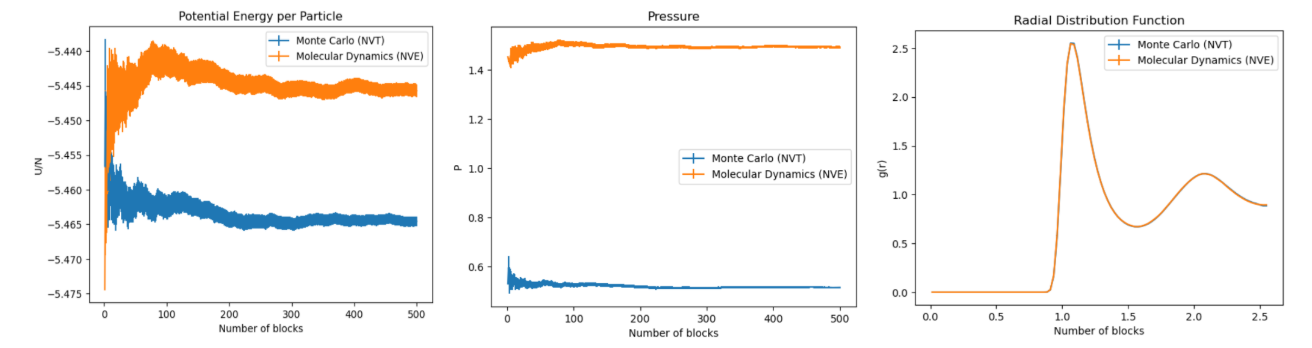

Si osserva un andamento medio ben definito, nel quale i risultati ottenuti con entrambe le metodologie convergono e si sovrappongono quasi completamente. Nel caso della funzione di distribuzione radiale $g(r)$, le due curve coincidono praticamente lungo un'unica linea. Per quanto riguarda invece l'energia potenziale e la pressione, si nota una lieve differenza, dovuta al fatto che la temperatura di equilibrio non raggiunge esattamente il valore teorico di $T^\star = 1.1$, ma si stabilizza intorno a $T^\star \approx 1.07$. Poiché sia la pressione sia l'energia sono grandezze particolarmente sensibili alle variazioni di temperatura, questa piccola discrepanza è sufficiente a produrre una leggera differenza tra le due curve. Nel complesso, la convergenza osservata dimostra che, nel limite termodinamico, entrambe le metodologie producono risultati equivalenti, confermando che il sistema ha raggiunto lo stato di equilibrio.


In [ ]:
import numpy as np
import math

# Potential energy
U_MC = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\U_MC.dat", skiprows=1)
U_MD = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\U_MC.dat", skiprows=1)

plt.errorbar(U_MC[:, 0], U_MC[:, 2], yerr=U_MC[:, 3], label='Monte Carlo (NVT)')
plt.errorbar(U_MD[:, 0], U_MD[:, 2], yerr=U_MD[:, 3], label='Molecular Dynamics (NVE)')
plt.title("Potential Energy per Particle")
plt.xlabel("Number of blocks")
plt.ylabel("U/N")
plt.legend()
plt.show()

# Pressure
P_MC = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\P_MC.dat", skiprows=1)
P_MD = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\P_MC.dat", skiprows=1)

plt.errorbar(P_MC[:, 0], P_MC[:, 2], yerr=P_MC[:, 3], label='Monte Carlo (NVT)')
plt.errorbar(P_MD[:, 0], P_MD[:, 2], yerr=P_MD[:, 3], label='Molecular Dynamics (NVE)')
plt.title("Pressure")
plt.xlabel("Number of blocks")
plt.ylabel("P")
plt.legend()
plt.show()

# Radial distribution
G_MC = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\G_MC.dat", skiprows=1)
G_MD = np.loadtxt(r"..\ex4\NSL_SIMULATOR\OUTPUT\7\G_MC.dat", skiprows=1)

plt.errorbar(G_MC[:, 0], G_MC[:, 1], yerr=G_MC[:, 2], label='Monte Carlo (NVT)')
plt.errorbar(G_MD[:, 0], G_MD[:, 1], yerr=G_MD[:, 2], label='Molecular Dynamics (NVE)')
plt.title("Radial Distribution Function")
plt.xlabel("Number of blocks")
plt.ylabel("g(r)")
plt.legend()
plt.show()